In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/temp.admin/Documents/Stats AIDS/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [7]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
613,6,105,80,28,0,32.5,0.878,26,0
675,6,195,70,0,0,30.9,0.328,31,1
737,8,65,72,23,0,32.0,0.600,42,0
378,4,156,75,0,0,48.3,0.238,32,1
404,5,168,64,0,0,32.9,0.135,41,1


In [8]:
for col in df.columns:
    unique_vals = df[col].nunique()
    if unique_vals ==2:
        print(f"{col} : Binary")
    elif df[col].dtype in ['int64','float64'] :
        print(f"{col}:Numerical")
    else :
        print(f"{col}:Categorical")


Pregnancies:Numerical
Glucose:Numerical
BloodPressure:Numerical
SkinThickness:Numerical
Insulin:Numerical
BMI:Numerical
DiabetesPedigreeFunction:Numerical
Age:Numerical
Outcome : Binary


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
(df==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [12]:
for col in df.columns[:-1]: #exclude Outcome
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR =Q3-Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df [(df [col] < lower) | (df [col] > upper)]
    print(f'{col}: {outliers.shape[0]} outliers')

Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 45 outliers
SkinThickness: 1 outliers
Insulin: 34 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers


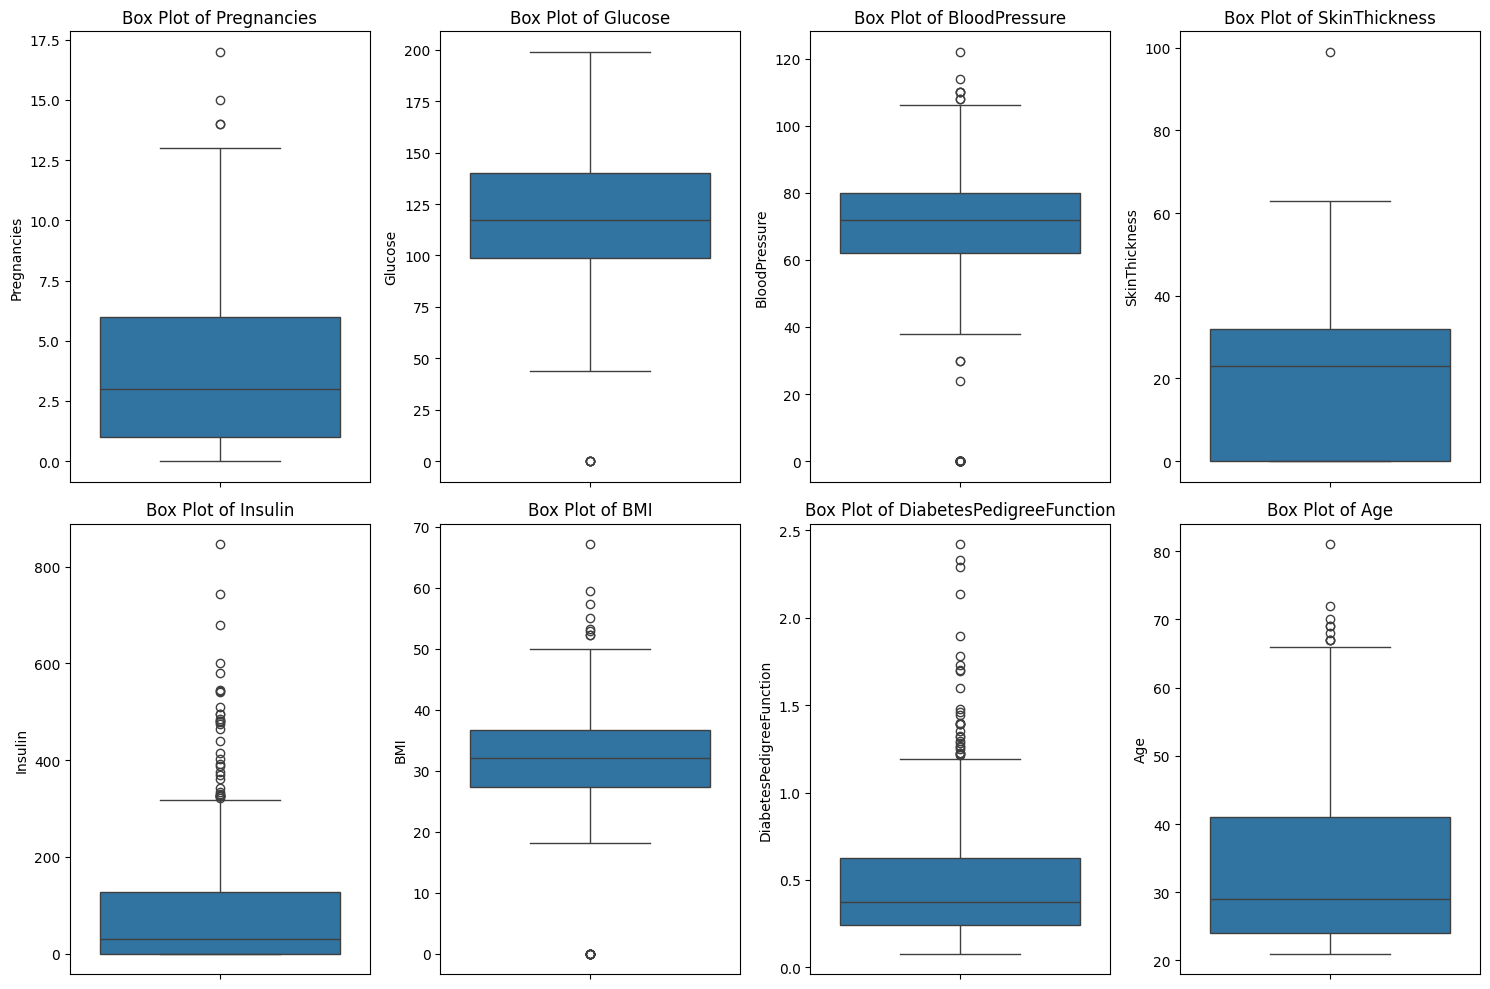

In [13]:
plt.figure(figsize = (15,10))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()

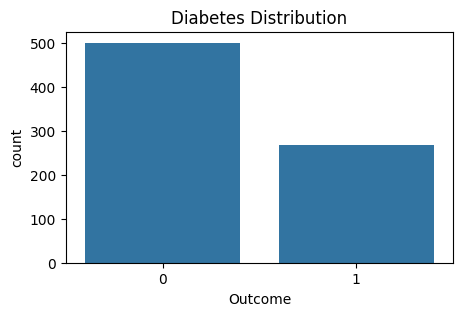

In [14]:
plt.figure(figsize = (5,3))
sns.countplot(x='Outcome', data = df)
plt.title("Diabetes Distribution")
plt.show()

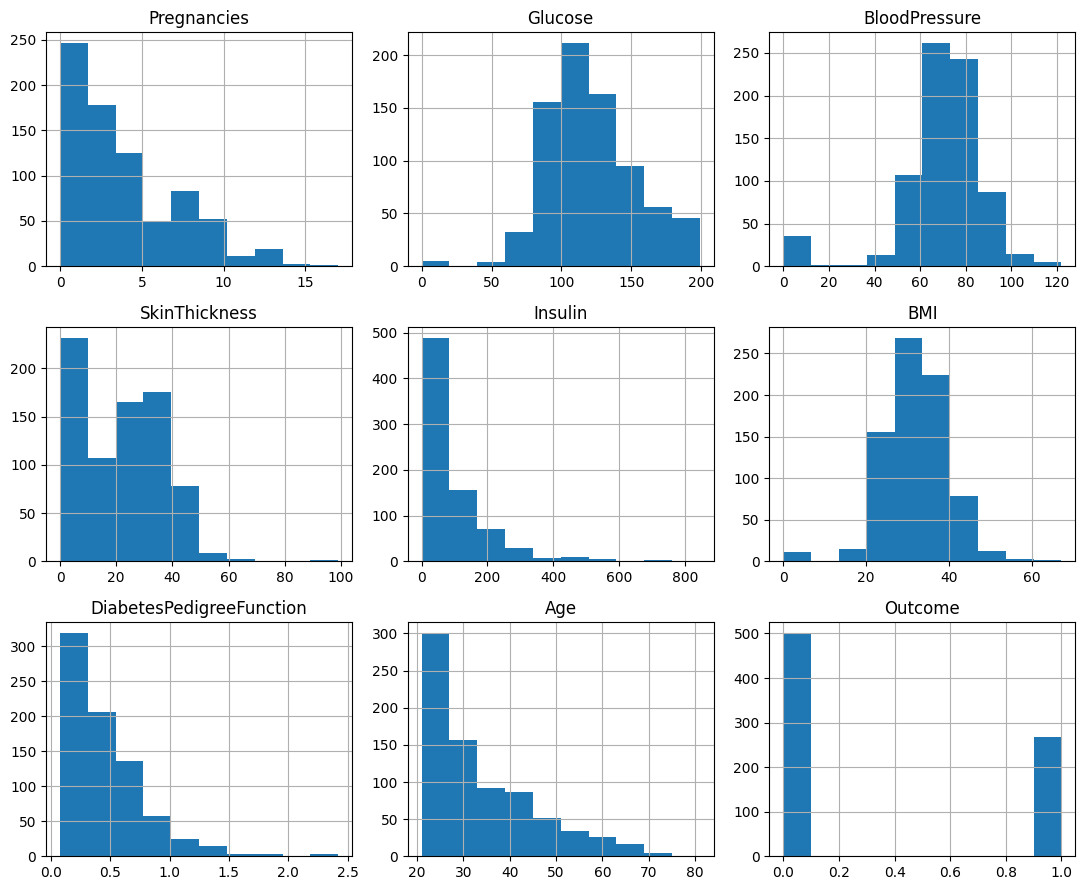

In [15]:

df.hist(figsize = (11,9))
plt.tight_layout()
plt.show()

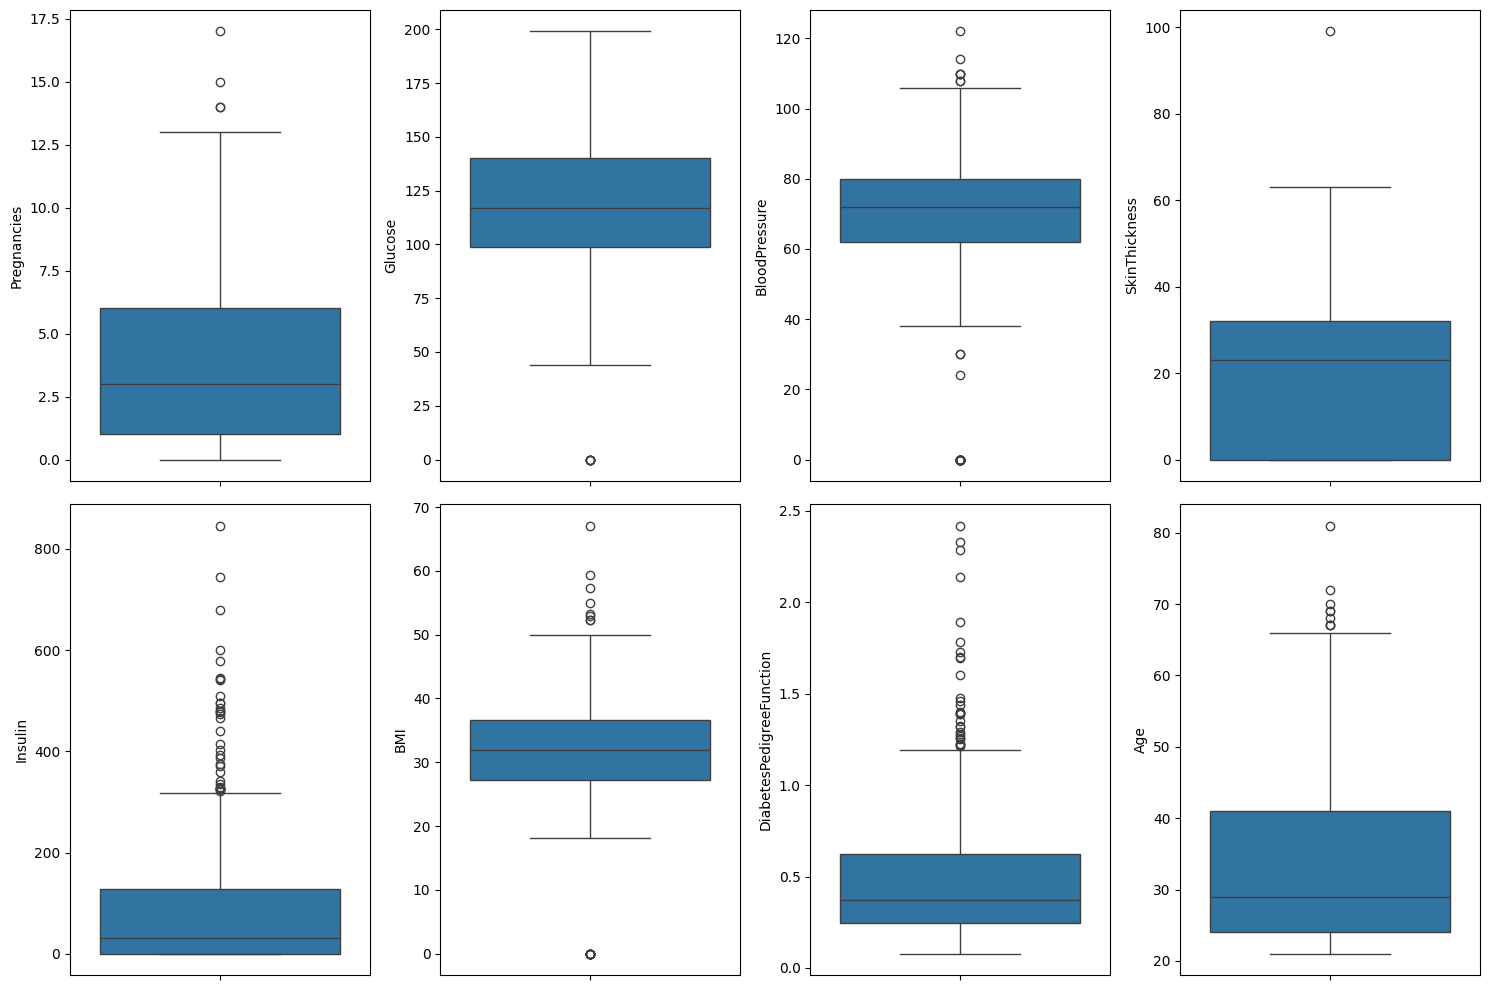

In [16]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

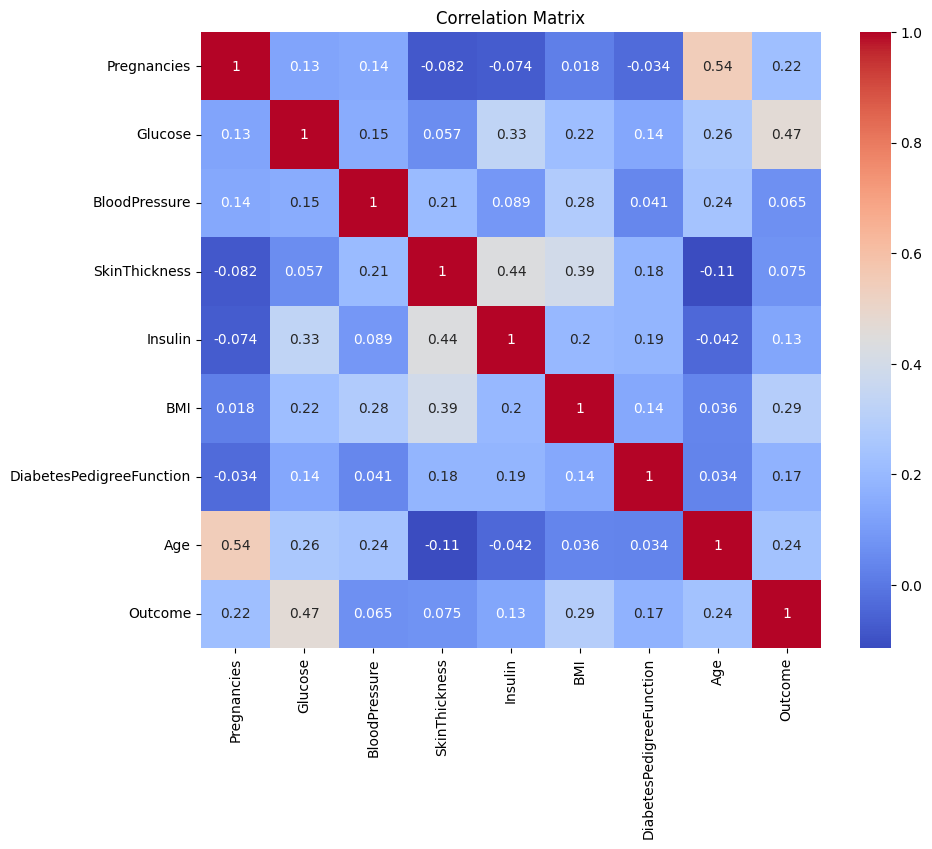

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

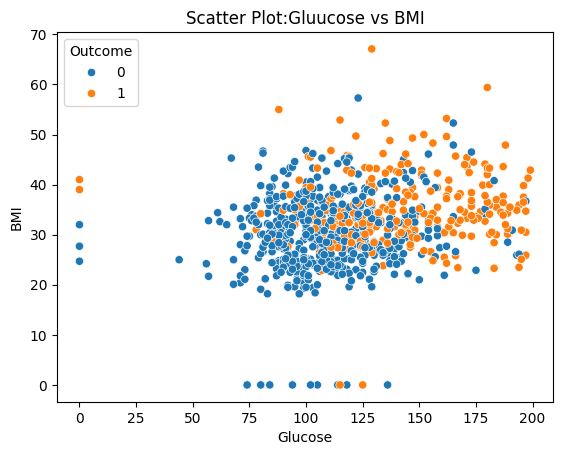

In [18]:
sns.scatterplot(x="Glucose",y="BMI",hue="Outcome",data=df)
plt.title("Scatter Plot:Gluucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

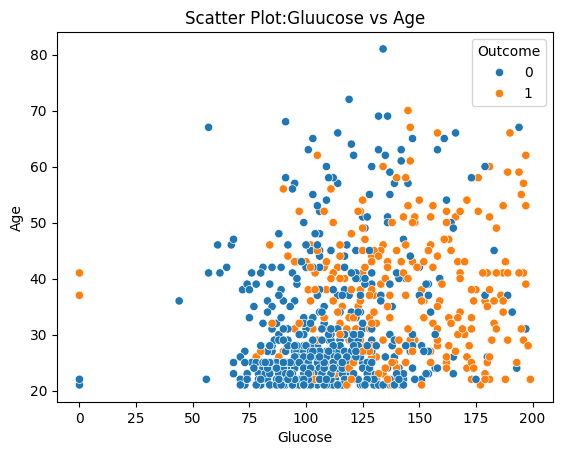

In [19]:
sns.scatterplot(x="Glucose",y="Age", hue="Outcome",data=df)
plt.title("Scatter Plot:Gluucose vs Age")
plt.xlabel("Glucose")
plt.ylabel("Age")
plt.show()

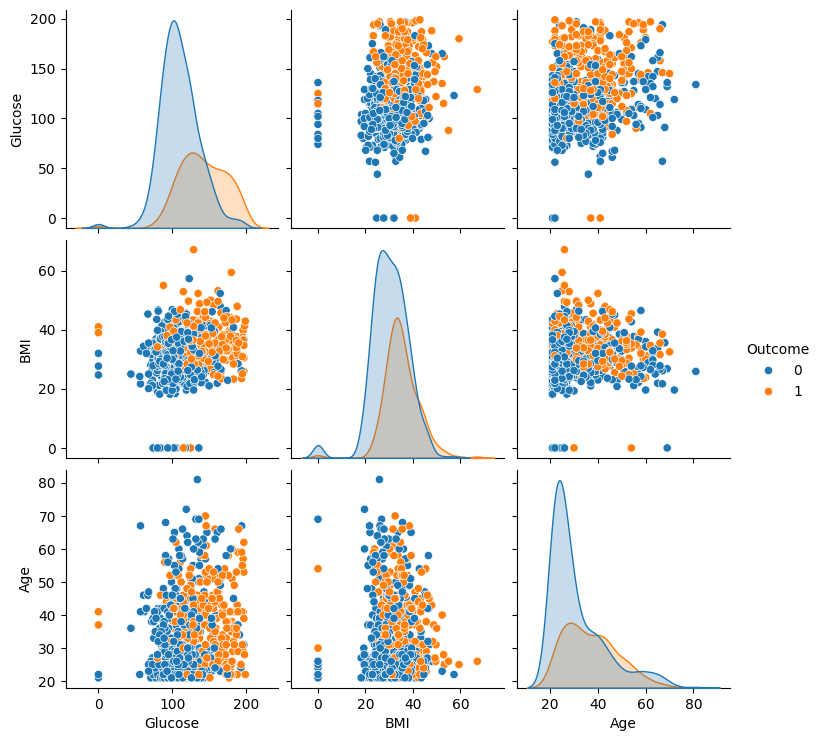

In [27]:
var=["Glucose","BMI","Age"]
sns.pairplot(data =df[var+["Outcome"]],vars=var,hue='Outcome')
plt.show()